In [1]:
%%writefile VECTOR_MATRIX_CUDA.cu
#include <iostream>
#include <cuda_runtime.h>
#include <chrono>
#include <fstream>
#include <vector>

using namespace std;

#define TILE 16

// ---------------- VECTOR ADD ----------------
__global__ void vectorAdd(float *A, float *B, float *C, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n)
        C[i] = A[i] + B[i];
}

// ---------------- MATRIX MUL (GLOBAL) ----------------
__global__ void matMulGlobal(float *A, float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0;
        for (int k = 0; k < N; k++)
            sum += A[row*N + k] * B[k*N + col];
        C[row*N + col] = sum;
    }
}

// ---------------- MATRIX MUL (SHARED) ----------------
__global__ void matMulShared(float *A, float *B, float *C, int N) {
    __shared__ float sA[TILE][TILE];
    __shared__ float sB[TILE][TILE];

    int row = blockIdx.y * TILE + threadIdx.y;
    int col = blockIdx.x * TILE + threadIdx.x;

    float sum = 0;

    for (int t = 0; t < N / TILE; t++) {
        sA[threadIdx.y][threadIdx.x] = A[row*N + t*TILE + threadIdx.x];
        sB[threadIdx.y][threadIdx.x] = B[(t*TILE + threadIdx.y)*N + col];

        __syncthreads();

        for (int i = 0; i < TILE; i++)
            sum += sA[threadIdx.y][i] * sB[i][threadIdx.x];

        __syncthreads();
    }

    C[row*N + col] = sum;
}

// ---------------- CPU MATRIX ----------------
void cpuMatMul(vector<float>& A, vector<float>& B, vector<float>& C, int N) {
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            float sum = 0;
            for (int k = 0; k < N; k++)
                sum += A[i*N+k] * B[k*N+j];
            C[i*N+j] = sum;
        }
}

// ---------------- MAIN ----------------
int main() {

    ofstream file("result.txt");
    file << "SIZE,CPU_TIME,GLOBAL_TIME,SHARED_TIME,SPEEDUP_GLOBAL,SPEEDUP_SHARED\n";

    vector<int> sizes = {256, 512, 1024, 2048};

    for (int N : sizes) {

        int vecSize = N * 1024;

        // ---------- VECTOR ----------
        float *A, *B, *C;
        cudaMallocManaged(&A, vecSize*sizeof(float));
        cudaMallocManaged(&B, vecSize*sizeof(float));
        cudaMallocManaged(&C, vecSize*sizeof(float));

        for (int i = 0; i < vecSize; i++) {
            A[i] = 1.0f;
            B[i] = 2.0f;
        }

        auto start = chrono::high_resolution_clock::now();
        for (int i = 0; i < vecSize; i++)
            C[i] = A[i] + B[i];
        auto end = chrono::high_resolution_clock::now();
        double cpuVec = chrono::duration<double, milli>(end - start).count();

        start = chrono::high_resolution_clock::now();
        vectorAdd<<<(vecSize+255)/256,256>>>(A,B,C,vecSize);
        cudaDeviceSynchronize();
        end = chrono::high_resolution_clock::now();
        double gpuVec = chrono::duration<double, milli>(end - start).count();

        cudaFree(A); cudaFree(B); cudaFree(C);

        // ---------- MATRIX ----------
        int size = N*N;
        vector<float> h_A(size,1.0f), h_B(size,2.0f), h_C(size);

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, size*sizeof(float));
        cudaMalloc(&d_B, size*sizeof(float));
        cudaMalloc(&d_C, size*sizeof(float));

        cudaMemcpy(d_A, h_A.data(), size*sizeof(float), cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_B.data(), size*sizeof(float), cudaMemcpyHostToDevice);

        // CPU
        start = chrono::high_resolution_clock::now();
        cpuMatMul(h_A, h_B, h_C, N);
        end = chrono::high_resolution_clock::now();
        double cpuTime = chrono::duration<double, milli>(end - start).count();

        dim3 threads(TILE,TILE);
        dim3 blocks(N/TILE,N/TILE);

        // Global
        start = chrono::high_resolution_clock::now();
        matMulGlobal<<<blocks,threads>>>(d_A,d_B,d_C,N);
        cudaDeviceSynchronize();
        end = chrono::high_resolution_clock::now();
        double globalTime = chrono::duration<double, milli>(end - start).count();

        // Shared
        start = chrono::high_resolution_clock::now();
        matMulShared<<<blocks,threads>>>(d_A,d_B,d_C,N);
        cudaDeviceSynchronize();
        end = chrono::high_resolution_clock::now();
        double sharedTime = chrono::duration<double, milli>(end - start).count();

        double speedupGlobal = cpuTime / globalTime;
        double speedupShared = cpuTime / sharedTime;

        cout << "N=" << N
             << " CPU=" << cpuTime
             << " Global=" << globalTime
             << " Shared=" << sharedTime << endl;

        file << N << ","
             << cpuTime << ","
             << globalTime << ","
             << sharedTime << ","
             << speedupGlobal << ","
             << speedupShared << "\n";

        cudaFree(d_A);
        cudaFree(d_B);
        cudaFree(d_C);
    }

    file.close();
    return 0;
}

Writing VECTOR_MATRIX_CUDA.cu


In [ ]:
!nvcc VECTOR_MATRIX_CUDA.cu -o vectorAdd && ./vectorAdd

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
N=256 CPU=110.757 Global=0.165277 Shared=0.095026
N=512 CPU=1136.12 Global=0.880042 Shared=0.548182
N=1024 CPU=13786.7 Global=9.23668 Shared=5.81276
^C


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("vector_matrix_result.txt")
print("Execution Results:")


# Calculate SPEEDUP_GLOBAL and SPEEDUP_SHARED
df["SPEEDUP_GLOBAL"] = df["CPU_TIME"] / df["GLOBAL_TIME"]
df["SPEEDUP_SHARED"] = df["CPU_TIME"] / df["SHARED_TIME"]

print(df)

Execution Results:
   SIZE    CPU_TIME  GLOBAL_TIME  SHARED_TIME  SPEEDUP_GLOBAL  SPEEDUP_SHARED
0   256     66.5147     0.363968     0.091368      182.748758      727.986823
1   512    669.5250     0.860374     0.555090      778.179024     1206.155759
2  1024   4777.7600     5.942640     4.319130      803.979376     1106.185736
3  2048  54949.8000    55.886800    35.436300      983.233966     1550.664149


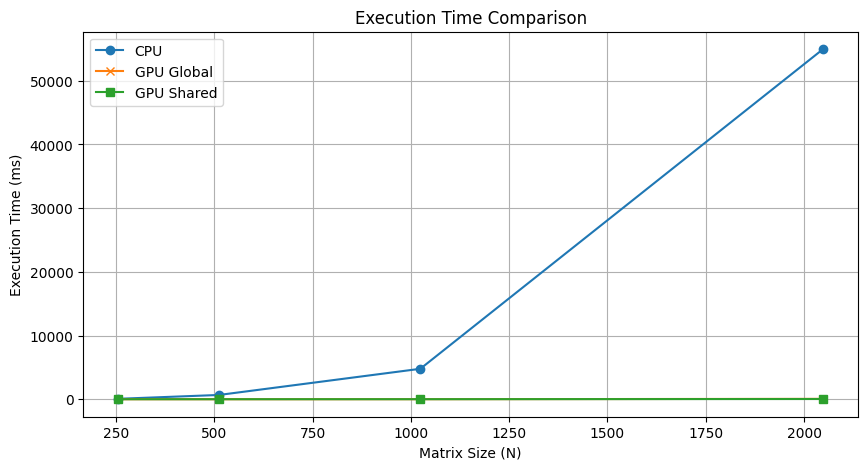

In [2]:
# ---------------- 1. TIME GRAPH ----------------
plt.figure(figsize=(10,5))
plt.plot(df.SIZE, df.CPU_TIME, marker='o', label="CPU")
plt.plot(df.SIZE, df.GLOBAL_TIME, marker='x', label="GPU Global")
plt.plot(df.SIZE, df.SHARED_TIME, marker='s', label="GPU Shared")
plt.xlabel("Matrix Size (N)")
plt.ylabel("Execution Time (ms)")
plt.title("Execution Time Comparison")
plt.legend()
plt.grid(True)
plt.show()

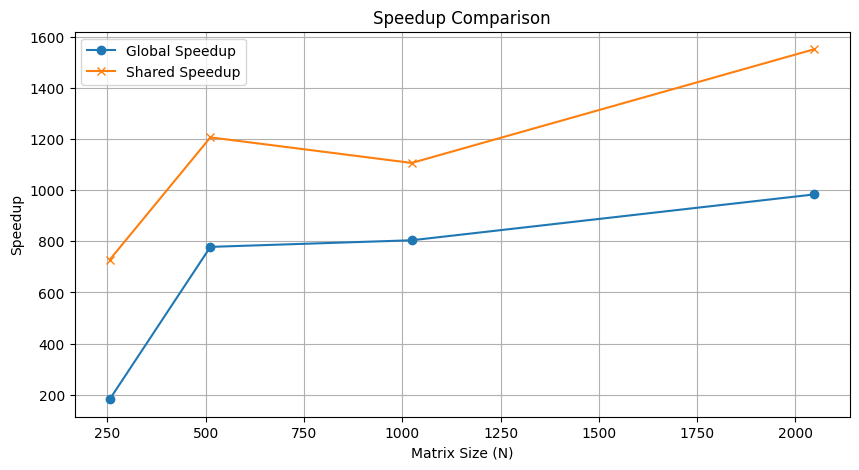

In [4]:
# ---------------- 2. SPEEDUP GRAPH ----------------
plt.figure(figsize=(10,5))
plt.plot(df.SIZE, df.SPEEDUP_GLOBAL, marker='o', label="Global Speedup")
plt.plot(df.SIZE, df.SPEEDUP_SHARED, marker='x', label="Shared Speedup")
plt.xlabel("Matrix Size (N)")
plt.ylabel("Speedup")
plt.title("Speedup Comparison")
plt.legend()
plt.grid(True)
plt.show()

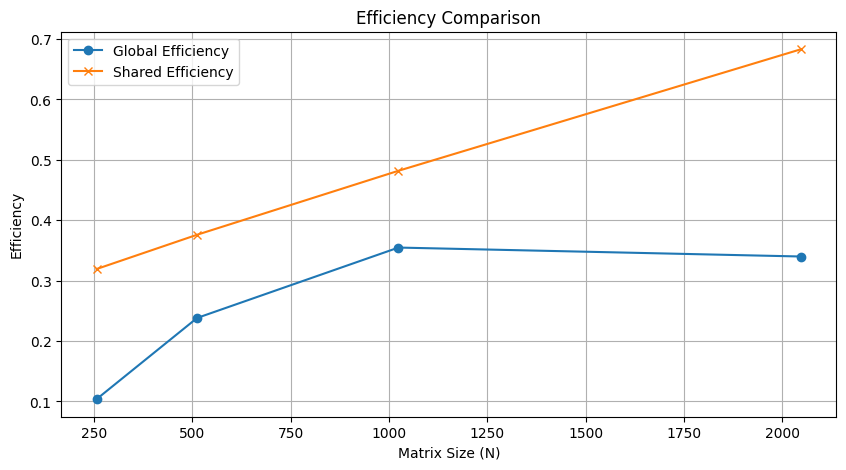

In [6]:
# ---------------- 3. EFFICIENCY GRAPH ----------------
# RTX 3060 CUDA cores
cores = 2560

df["EFF_GLOBAL"] = df["SPEEDUP_GLOBAL"] / cores
df["EFF_SHARED"] = df["SPEEDUP_SHARED"] / cores

plt.figure(figsize=(10,5))
plt.plot(df.SIZE, df.EFF_GLOBAL, marker='o', label="Global Efficiency")
plt.plot(df.SIZE, df.EFF_SHARED, marker='x', label="Shared Efficiency")
plt.xlabel("Matrix Size (N)")
plt.ylabel("Efficiency")
plt.title("Efficiency Comparison")
plt.legend()
plt.grid(True)
plt.show()